# Counting drupletes in a raspberry
First, the necessary libraries are imported:

In [1]:
import qim3d

## 1. 📂 Loading the data
The `qim3d` library's `io.Downloader()` is used to load in the raspberry volumetric data from the QIM data repository:

In [2]:
downloader = qim3d.io.Downloader()
data = downloader.Raspberry.Raspberry2_DOWNSAMPLED(load_file=True)

File already downloaded:
/home/s215170/Repos/qim3d/docs/notebooks/Raspberry/Raspberry2_DOWNSAMPLED.tif

Loading Raspberry2_DOWNSAMPLED.tif
Using virtual stack


The volume is converted to the OME-Zarr format to enable faster, more memory-efficient analysis by working with a chunked, multiscale version of the volume that is optimized for on-demand access. The `qim3d` library's `io.export_ome_zarr()` converts the volume to this format and exports it:

In [3]:
qim3d.io.export_ome_zarr("Raspberry.zarr", data, chunk_size=100, downsample_rate=2, replace=True)

Exporting data to OME-Zarr format at Raspberry.zarr
Number of scales: 4

Converting input data to Dask array
 - shape...: (400, 500, 500)
 - chunks..: (100, 100, 100)

Calculating the multi-scale pyramid
- Scale 0: (400, 500, 500)
- Scale 1: (200, 250, 250)
- Scale 2: (100, 125, 125)
- Scale 3: (50, 62, 62)
Writing data to disk


Saving:   0%|          | 0.00/123 [00:00<?, ?Chunks/s]


All done!


Now, the OME-Zarr volume is loaded in:

In [4]:
volume = qim3d.io.import_ome_zarr("Raspberry.zarr", scale=1, load=True)

Data contains 4 scales:
- Scale 0: (400, 500, 500)
- Scale 1: (200, 250, 250)
- Scale 2: (100, 125, 125)
- Scale 3: (50, 62, 62)

Loading scale 1 with shape (200, 250, 250)


## 2. 🔍 Exploring the data
Now it is time to get an understanding of the raspberry data. To do this, `qim3d`'s `viz.slices_grid()` is used to show 15 different slices of the volume. An appropriate color map is used:

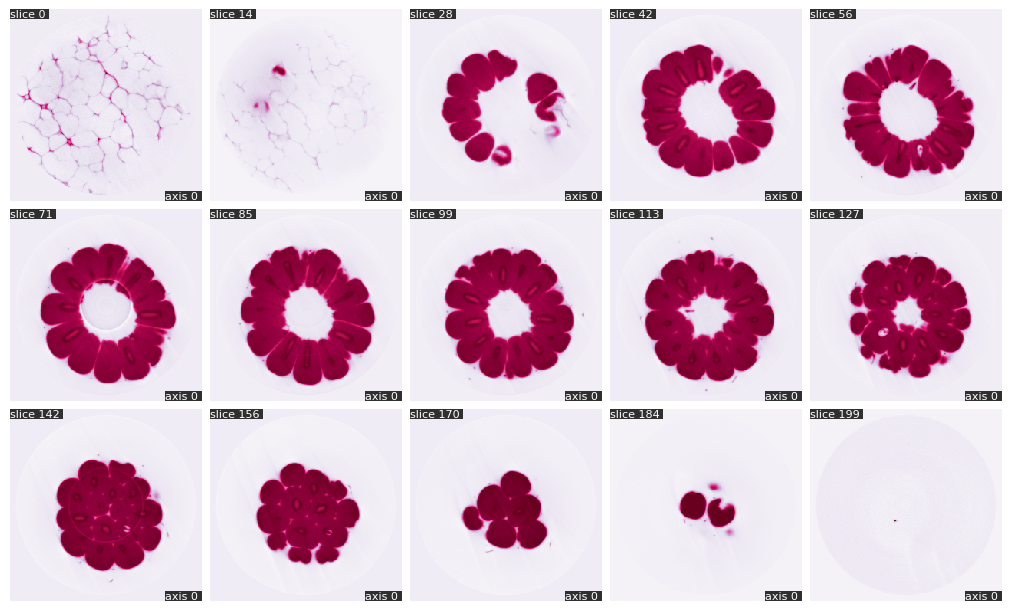

In [5]:
qim3d.viz.slices_grid(volume, n_slices=15, colormap='PuRd')

The entire volume can be rendered using `qim3d`'s `viz.volumetric()`. The minimum (vmin) and maximum (vmax) voxel intensities that are rendered can be chosen and passed into the function or chosen manually in the rendered window on the right hand side. The ones in this example were found through trial and error and then coded into the function.

In [6]:
qim3d.viz.volumetric(volume, min_value=30_000, colormap='Reds')

Output()

## 3. 🫐 Segmenting drupletes

We'll try to different approaches for this problem.

### Using qim3d only

Here we use only functionalities built into the `qim3d` library. We'll use `qim3d.segmentation.watershed` for this. 

Firstly, we need to create a binary volume to segment. We start off applying a smoothing filter to the volume. After this, we use `qim3d`'s `viz.threshold()` to find a suiting threshold.

In [7]:
blurred_vol = qim3d.filters.gaussian(volume, sigma=3)

qim3d.viz.threshold(blurred_vol, colormap='Reds')

A threshold of about 30000 - found using Otsu's method - seems good.

In [8]:
bin_vol = blurred_vol > 30_000

qim3d.viz.slicer_orthogonal(bin_vol)

In [9]:
labeled_vol, num_labels = qim3d.segmentation.watershed(bin_vol, min_distance=6)

cmap = qim3d.viz.colormaps.segmentation(num_labels, min_dist=0.7)

qim3d.viz.volumetric(labeled_vol, colormap=cmap, opacity_function="constant")

Total number of objects found: 55


Output()

As seen in the render, the segmentation is far from perfect. Therefore, we'll attempt a more manual approach to see if we can improve the results.

### Manual attempt: watershed distance transform

Here we attempt a slightly different version of what `qim3d.segmentation.watershed` does, but we will have more freedom to fit this exact problem. First, we apply a gaussian filter from `qim3d`, after which we threshold the volume using otsu's method:

In [10]:
from skimage.filters import threshold_otsu
from scipy.ndimage import distance_transform_edt

blurred_vol = qim3d.filters.gaussian(volume, sigma=3)

bin_vol = blurred_vol > threshold_otsu(blurred_vol)

qim3d.viz.slicer_orthogonal(bin_vol)


We now apply a distance transform to the resulting binary volume:

In [11]:
dist_vol = distance_transform_edt(bin_vol)

qim3d.viz.slicer_orthogonal(dist_vol)

We now count the number of local maxima in the distance transform:

In [12]:
from skimage.feature import peak_local_max

local_max = peak_local_max(dist_vol, min_distance=9)
print(f'Number of local maxima: {len(local_max)}')

Number of local maxima: 49


We now create a new copy of the volume where we add clusters at the found local maxima for visualization:

In [13]:
import numpy as np
vol_highlighted = volume.copy() / 2  # Dim the original volume a bit to highlight the markers better
VERY_HIGH_VALUE = 65504 # Max value for float16
RADIUS = 5

# Precompute a spherical mask (3D ball)
z, y, x = np.ogrid[-RADIUS:RADIUS+1, -RADIUS:RADIUS+1, -RADIUS:RADIUS+1]
sphere = x**2 + y**2 + z**2 <= RADIUS**2

# Apply the sphere at each local max
for coord in local_max:
    cz, cy, cx = coord
    z1, z2 = max(cz - RADIUS, 0), min(cz + RADIUS + 1, dist_vol.shape[0])
    y1, y2 = max(cy - RADIUS, 0), min(cy + RADIUS + 1, dist_vol.shape[1])
    x1, x2 = max(cx - RADIUS, 0), min(cx + RADIUS + 1, dist_vol.shape[2])

    sz1, sz2 = z1 - (cz - RADIUS), z2 - (cz - RADIUS)
    sy1, sy2 = y1 - (cy - RADIUS), y2 - (cy - RADIUS)
    sx1, sx2 = x1 - (cx - RADIUS), x2 - (cx - RADIUS)

    vol_highlighted[z1:z2, y1:y2, x1:x2][sphere[sz1:sz2, sy1:sy2, sx1:sx2]] = VERY_HIGH_VALUE


qim3d.viz.volumetric(vol_highlighted, min_value=20_000, colormap='Reds')

Output()

As seen above, the results are not perfect, but it correctly identifies the center of the majority of the drupletes.

Now the watershed algorithm is applied:

In [14]:
from skimage.segmentation import watershed
from scipy.ndimage import label

mask = np.zeros(dist_vol.shape, dtype=bool)
mask[tuple(local_max.T)] = True

markers, _ = label(mask)
labels = watershed(-dist_vol, markers, mask=bin_vol)

print(f"Number of drupelets found: {len(np.unique(labels))}")

Number of drupelets found: 50


In [15]:
cmap = qim3d.viz.colormaps.segmentation(len(np.unique(labels)))
qim3d.viz.volumetric(labels, colormap=cmap, opacity_function="constant")

Output()

Again, the results are not perfect. They are, however, slightly better than those achieved using only the qim3d implementations.